# Assignment 1: Feature-Based Semantic Role Labeling

**Model download link:** [Download trained model](https://drive.google.com/drive/folders/1cBWbba5ksZcSRVrCOjdPXHSC_GFuupNH?usp=sharing)

This notebook implements a token-level Semantic Role Labeler (SRL) trained on the Universal PropBank v1.0 English dataset using Logistic Regression with three linguistically motivated features. The pipeline covers data loading and preprocessing, feature extraction, training, evaluation, and inference on standalone sentences.

## 0. Setup

In [7]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 8.6 MB/s eta 0:00:0000:0100:02

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

from preprocessing import parse_conllu
from features import extract_features, get_spacy_doc
from train import build_features, train_and_evaluate, predict_srl, load_model

DATA_DIR  = Path("../data")     # remove ../ if you are only running a1, and place data in this dir
MODEL_DIR = Path("model")
OUT_DIR   = Path("output")
OUT_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "en_ewt-up-train.conllu"
TEST_PATH  = DATA_DIR / "en_ewt-up-test.conllu"

## 1. Data Loading and Statistics

We use the Universal PropBank v1.0 English dataset in CoNLL-U format. A key preprocessing step is **sentence replication**: sentences with multiple predicates are replicated once per predicate so that every training instance corresponds to a single predicate and its argument structure. Additionally, tokens labeled `V` (the predicate itself) are excluded from training since their identity is given as input — predicting them would be trivial and would pollute the label space.

In [4]:
print("Parsing training data...")
train_ws, train_stats = parse_conllu(TRAIN_PATH)

print("Parsing test data...")
test_ws, test_stats = parse_conllu(TEST_PATH)

print("\n--- Dataset Statistics ---")
print(f"{'':30s} {'Train':>12} {'Test':>12}")
print("-" * 56)
print(f"{'Sentences (pre-replication)':30s} {train_stats['pre_replication_sentences']:>12,} {test_stats['pre_replication_sentences']:>12,}")
print(f"{'Tokens (pre-replication)':30s} {train_stats['pre_replication_tokens']:>12,} {test_stats['pre_replication_tokens']:>12,}")
print(f"{'Sentences (post-replication)':30s} {train_stats['post_replication_sentences']:>12,} {test_stats['post_replication_sentences']:>12,}")
print(f"{'Tokens (post-replication)':30s} {train_stats['post_replication_tokens']:>12,} {test_stats['post_replication_tokens']:>12,}")

Parsing training data...
Parsing test data...

--- Dataset Statistics ---
                                      Train         Test
--------------------------------------------------------
Sentences (pre-replication)          12,543        2,077
Tokens (pre-replication)            204,585       25,096
Sentences (post-replication)         40,482        4,799
Tokens (post-replication)         1,028,137      101,144


In [5]:
cols = ["sent_idx", "token_id", "word", "predicate_word", "predicate_idx", "full_tokens", "label"]
df_train = pd.DataFrame(train_ws, columns=cols)
df_test  = pd.DataFrame(test_ws,  columns=cols)

print(f"Training rows (token x predicate instances): {len(df_train):,}")
print(f"Test rows (token x predicate instances):     {len(df_test):,}")
df_train.head(10)

Training rows (token x predicate instances): 1,028,137
Test rows (token x predicate instances):     101,144


,sent_idx,token_id,word,predicate_word,predicate_idx,full_tokens,label
0,1,1,Al,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",O
1,1,2,-,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",O
2,1,3,Zaman,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",O
3,1,4,:,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",O
4,1,5,American,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",O
5,1,6,forces,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",ARG0
6,1,7,killed,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",O
7,1,8,Shaikh,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",ARG1
8,1,9,Abdullah,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",O
9,1,10,al,killed,6,"[Al, -, Zaman, :, American, forces, killed, Sh...",O


### 1.1 Label Distribution

In [6]:
# Training set labels
train_label_counts = df_train['label'].value_counts()
print(f"Unique labels in training set: {len(train_label_counts)}")

# Test set labels
test_label_counts = df_test['label'].value_counts()
print(f"Unique labels in test set: {len(test_label_counts)}")

# Combined
all_labels = sorted(set(df_train['label'].unique()) | set(df_test['label'].unique()))
print(f"Combined unique labels: {len(all_labels)}")
print(f"In test but not train: {set(df_test['label'].unique()) - set(df_train['label'].unique())}")

label_df = pd.DataFrame({
    'label': all_labels,
    'train_count': [train_label_counts.get(l, 0) for l in all_labels],
    'test_count': [test_label_counts.get(l, 0) for l in all_labels],
})
label_df['total'] = label_df['train_count'] + label_df['test_count']
label_df = label_df.sort_values('total', ascending=False).reset_index(drop=True)
print("\nLabel distribution:")
print(label_df.to_string(index=False))

Unique labels in training set: 59
Unique labels in test set: 44
Combined unique labels: 60
In test but not train: {'R-ARGM-ADJ'}

Label distribution:
     label  train_count  test_count   total
         O       945685       91709 1037394
      ARG1        27672        3241   30913
      ARG0        15283        1733   17016
      ARG2         9829        1129   10958
  ARGM-TMP         5331         543    5874
  ARGM-ADV         4431         496    4927
  ARGM-MOD         3570         442    4012
  ARGM-NEG         1909         216    2125
  ARGM-ADJ         1691         228    1919
  ARGM-LOC         1630         207    1837
  ARGM-MNR         1490         148    1638
  ARGM-DIS         1426         182    1608
  ARGM-EXT          874         105     979
  ARGM-PRP          719          75     794
      ARG3          656          74     730
    R-ARG0          644          67     711
    R-ARG1          654          52     706
  ARGM-CAU          598          46     644
  ARGM-PRR    

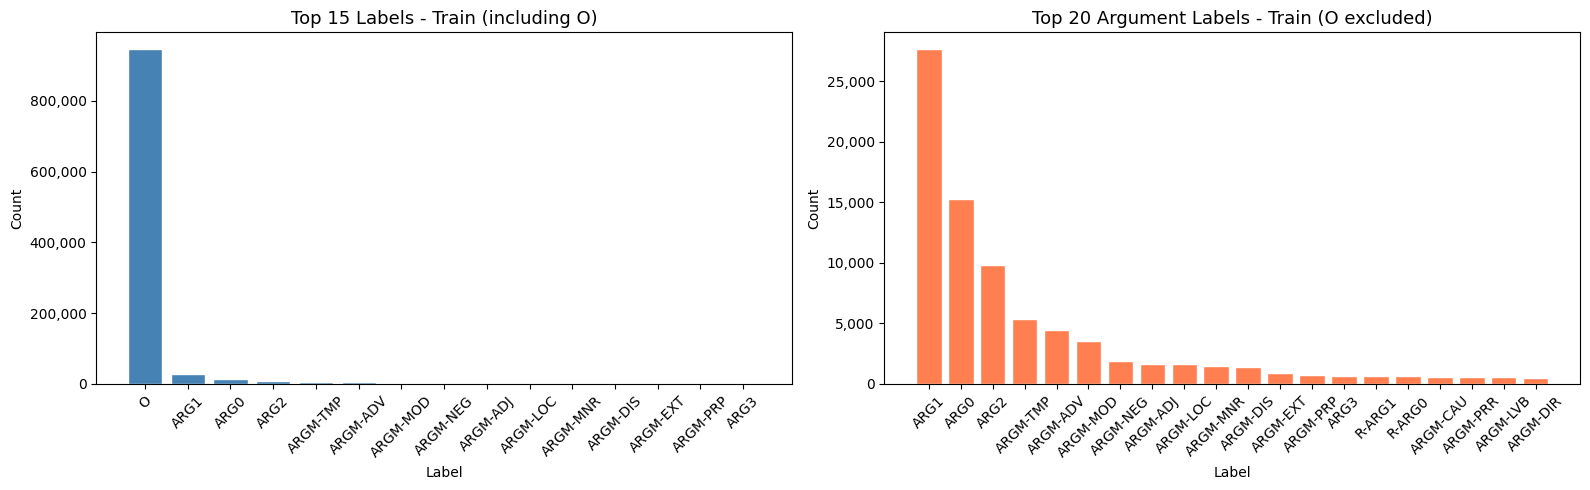

O accounts for 92.0% of train tokens and 90.7% of test tokens


In [7]:
# Plot label distribution for BOTH train and test
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: top 15 labels including O (train set)
top_all = train_label_counts.head(15)
axes[0].bar(top_all.index, top_all.values, color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Labels - Train (including O)', fontsize=13)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right plot: top 20 argument labels excluding O (train set)
arg_counts = train_label_counts[train_label_counts.index != 'O'].head(20)
axes[1].bar(arg_counts.index, arg_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Top 20 Argument Labels - Train (O excluded)', fontsize=13)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(OUT_DIR / 'label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

o_pct_train = train_label_counts['O'] / train_label_counts.sum() * 100
o_pct_test = test_label_counts['O'] / test_label_counts.sum() * 100
print(f"O accounts for {o_pct_train:.1f}% of train tokens and {o_pct_test:.1f}% of test tokens")

### 1.2 Most Frequent Predicates and Argument-Filling Words

In [13]:
print("Top 15 predicates (train):")
print(df_train['predicate_word'].value_counts().head(15).to_string())

print("\nTop 15 words filling ARG0 (agent/subject):")
print(df_train[df_train['label'] == 'ARG0']['word'].value_counts().head(15).to_string())

print("\nTop 15 words filling ARG1 (patient/theme):")
print(df_train[df_train['label'] == 'ARG1']['word'].value_counts().head(15).to_string())

Top 15 predicates (train):
predicate_word
is      52201
have    33530
was     32259
be      28287
are     26781
do      18195
has     13637
had     12782
were    10349
been     9315
get      9156
know     7737
's       6916
did      6505
said     6381

Top 15 words filling ARG0 (agent/subject):
word
I       3099
you     1493
they     730
we       628
he       590
We       320
They     267
i        244
You      223
He       201
she      192
it       187
your     154
me       141
Bush     139

Top 15 words filling ARG1 (patient/theme):
word
it      1213
I        811
you      564
they     330
what     297
me       289
It       267
this     265
he       225
them     212
him      195
that     177
know     154
one      149
we       139


## 2. Feature Extraction

We extract exactly three features per token. SpaCy (`en_core_web_lg`) provides dependency parses, lemmas, and named entity annotations. A critical implementation detail: we create SpaCy `Doc` objects from pre-tokenized CoNLL-U word lists (preserving dataset tokenization) and then run the full pipeline via `nlp(doc)`, which ensures `tok2vec` runs first. Without `tok2vec`, the tagger and parser lack contextual embeddings and produce degenerate parses.

### Feature 1 (Mandatory): Directed Dependency Path + Predicate Lemma

**Motivation:** Semantic roles are defined relative to a predicate, and the dependency tree encodes the grammatical relationship between a token and its governing verb. The path from a token to its predicate through the dependency tree captures this relationship in a linguistically meaningful way. For example, direct subjects (`nsubj:up`) are almost always ARG0 (agent), and direct objects (`dobj:up`) are almost always ARG1 (patient/theme). By appending the predicate's lemma, the feature also captures verb-specific argument patterns (e.g., the verb *give* assigns ARG2 to prepositional objects differently than *put*). The feature is decomposed into three dict keys: `dep_path_full` (path + lemma), `dep_path_only` (path alone, generalizes across verbs), and `pred_lemma` (verb-specific signal).

**Representation:** A string like `nsubj:up|enjoy` encoded as a sparse one-hot column by `DictVectorizer`. Suitable for Logistic Regression as each path-lemma combination becomes an independent binary feature.

### Feature 2: Token Lemma

**Motivation:** The lexical identity of a token is a strong signal for its semantic role, independent of its syntactic position. Certain words are semantically predisposed to certain roles: person names and organization words (e.g. "John", "government") tend to fill agent roles (ARG0), while inanimate nouns tend toward patient roles (ARG1). Pronouns like "it" or "they" also carry strong role tendencies. Using the lemma rather than the raw word form groups inflected variants together ("companies" and "company" map to the same feature value), improving generalization. This feature adds lexical information that is genuinely orthogonal to the dependency path, the path tells you *where* a token is structurally, the lemma tells you *what* it is.

**Representation:** Lemma string, one-hot encoded via `DictVectorizer`. High-frequency lemmas provide reliable signal; rare ones fall back to the dependency path feature.

### Feature 3: Named Entity Type

**Motivation:** Named entity type provides semantic category information that pure syntax cannot capture. SpaCy's NER assigns types such as PERSON, ORG, GPE, LOC, DATE, and TIME, which correlate strongly with semantic roles: PERSON and ORG entities are likely agents (ARG0), GPE and LOC entities are likely locative modifiers (ARGM-LOC), and DATE and TIME entities are likely temporal modifiers (ARGM-TMP). Tokens that are not part of any named entity return `NONE`, which is itself informative since non-entities are less likely to be core arguments. Like the token lemma, this feature adds semantic information that the dependency path alone cannot provide.

**Representation:** Entity type string (~20 SpaCy NER categories + `NONE`), one-hot encoded. Small fixed vocabulary produces clean sparse columns suitable for Logistic Regression.

### 2.1 Feature Examples

In [14]:
# Find short sentences with a single predicate for clarity
example_indices = []
for sent_idx in df_train['sent_idx'].unique():
    rows = df_train[df_train['sent_idx'] == sent_idx]
    if rows['predicate_word'].nunique() == 1 and len(rows['word'].unique()) < 12:
        example_indices.append(sent_idx)
    if len(example_indices) == 3:
        break

for sent_idx in example_indices:
    rows = df_train[df_train['sent_idx'] == sent_idx].drop_duplicates('word')
    sample_row = rows.iloc[0]
    full_tokens   = sample_row['full_tokens']
    predicate_idx = sample_row['predicate_idx']
    predicate     = sample_row['predicate_word']

    doc  = get_spacy_doc(full_tokens)
    feats = extract_features(doc, full_tokens, predicate_idx)

    print(f"\nSentence: {' '.join(full_tokens)}")
    print(f"Predicate: '{predicate}' (position {predicate_idx})")
    print(f"{'Token':15s} {'Label':12s} {'dep_path_full':35s} {'token_lemma':15s} {'ner_type'}")
    print("-" * 85)
    for _, row in rows.iterrows():
        token_idx = int(row['token_id']) - 1
        f = feats[token_idx]
        print(f"{row['word']:15s} {row['label']:12s} {f['dep_path_full']:35s} {f['token_lemma']:15s} {f['ner_type']}")


Sentence: Guerrillas killed an engineer , Asi Ali , from Tikrit .
Predicate: 'killed' (position 1)
Token           Label        dep_path_full                       token_lemma     ner_type
-------------------------------------------------------------------------------------
Guerrillas      ARG0         nsubj:up|kill                       guerrilla       NONE
killed          O            SELF|kill                           kill            NONE
an              O            det:up>dobj:up|kill                 an              NONE
engineer        ARG1         dobj:up|kill                        engineer        NONE
,               O            punct:up>dobj:up|kill               ,               NONE
Asi             O            compound:up>appos:up>dobj:up|kill   Asi             PERSON
Ali             O            appos:up>dobj:up|kill               Ali             PERSON
from            O            prep:up>dobj:up|kill                from            NONE
Tikrit          O            pob

### 2.2 Dependency Path Analysis

To empirically validate Feature 1, we inspect the label distributions for the most frequent dependency paths in the training set. A useful feature should show that certain paths reliably predict certain labels.

In [15]:
print("Extracting features for path analysis...")
train_feats, train_labels = build_features(train_ws)
print(f"Done. {len(train_feats):,} feature dicts extracted.")

Extracting features for path analysis...
  row 0/1028137 (0%)
  row 50000/1028137 (4%)
  row 100000/1028137 (9%)
  row 150000/1028137 (14%)
  row 200000/1028137 (19%)
  row 250000/1028137 (24%)
  row 300000/1028137 (29%)
  row 350000/1028137 (34%)
  row 400000/1028137 (38%)
  row 450000/1028137 (43%)
  row 500000/1028137 (48%)
  row 550000/1028137 (53%)
  row 600000/1028137 (58%)
  row 650000/1028137 (63%)
  row 700000/1028137 (68%)
  row 750000/1028137 (72%)
  row 800000/1028137 (77%)
  row 850000/1028137 (82%)
  row 900000/1028137 (87%)
  row 950000/1028137 (92%)
  row 1000000/1028137 (97%)
  10149 unique sentences parsed.
Done. 1,028,137 feature dicts extracted.


In [16]:
# Analyze dep_path_only -> label distributions
from collections import defaultdict

path_label_counts = defaultdict(Counter)
for feat, label in zip(train_feats, train_labels):
    path_label_counts[feat['dep_path_only']][label] += 1

path_totals = {p: sum(c.values()) for p, c in path_label_counts.items()}
top_paths = sorted(path_totals, key=path_totals.get, reverse=True)[:15]

print(f"Unique dep_path_only values: {len(path_totals):,}")
print(f"\n{'Path':40s} {'Total':>8s}  Top labels")
print("-" * 90)
for path in top_paths:
    total = path_totals[path]
    top3 = path_label_counts[path].most_common(3)
    top3_str = ", ".join(f"{l}:{n}" for l, n in top3)
    print(f"{path:40s} {total:>8,}  {top3_str}")

Unique dep_path_only values: 246,660

Path                                        Total  Top labels
------------------------------------------------------------------------------------------
SELF                                       40,482  O:40476, C-V:6
NOPATH                                     30,067  O:29952, ARG1:24, ARGM-ADV:22
punct:up                                   17,212  O:17182, ARG1-DSP:12, C-ARG1-DSP:7
nsubj:up                                   16,315  ARG0:8476, ARG1:5261, O:1699
prep:up                                    11,154  O:10850, C-ARG1:80, C-ARG2:47
pobj:up>prep:up                             9,922  ARG2:2168, ARG1:1786, O:1667
dobj:up                                     9,737  ARG1:7808, ARG2:590, O:586
aux:up                                      9,647  O:6596, ARGM-MOD:3036, ARGM-NEG:7
advmod:up                                   6,982  ARGM-TMP:1681, ARGM-ADV:1606, O:971
cc:up                                       4,085  O:3917, ARGM-DIS:166, ARG2:1
conj:

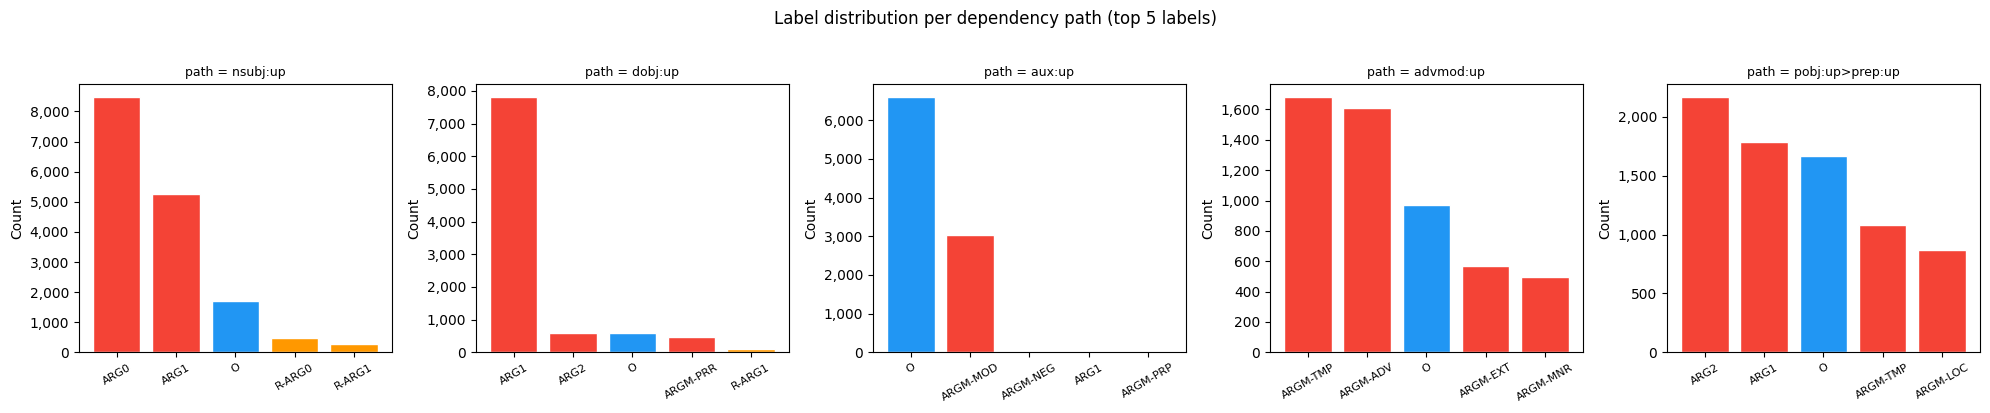

In [17]:
# Visualize: for key paths, show label precision
informative_paths = ['nsubj:up', 'dobj:up', 'aux:up', 'advmod:up', 'pobj:up>prep:up']

fig, axes = plt.subplots(1, len(informative_paths), figsize=(20, 4))
for ax, path in zip(axes, informative_paths):
    counts = path_label_counts.get(path, Counter())
    top5 = counts.most_common(5)
    labels_plot = [l for l, _ in top5]
    values_plot = [v for _, v in top5]
    colors = ['#2196F3' if l == 'O' else '#F44336' if l.startswith('ARG') else '#FF9800' for l in labels_plot]
    ax.bar(labels_plot, values_plot, color=colors, edgecolor='white')
    ax.set_title(f'path = {path}', fontsize=9)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Label distribution per dependency path (top 5 labels)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'path_label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Training

In [18]:
model, vectorizer = train_and_evaluate(
    str(TRAIN_PATH),
    str(TEST_PATH),
    output_dir=str(MODEL_DIR)
)

TRAINING

Parsing training data...
  Pre-replication:  12543 sentences, 204585 tokens
  Post-replication: 40482 sentences, 1028137 tokens

Extracting training features...
  row 0/1028137 (0%)
  row 50000/1028137 (4%)
  row 100000/1028137 (9%)
  row 150000/1028137 (14%)
  row 200000/1028137 (19%)
  row 250000/1028137 (24%)
  row 300000/1028137 (29%)
  row 350000/1028137 (34%)
  row 400000/1028137 (38%)
  row 450000/1028137 (43%)
  row 500000/1028137 (48%)
  row 550000/1028137 (53%)
  row 600000/1028137 (58%)
  row 650000/1028137 (63%)
  row 700000/1028137 (68%)
  row 750000/1028137 (72%)
  row 800000/1028137 (77%)
  row 850000/1028137 (82%)
  row 900000/1028137 (87%)
  row 950000/1028137 (92%)
  row 1000000/1028137 (97%)
  10149 unique sentences parsed.

Vectorizing...
  Feature matrix shape: (1028137, 801458)

Training Logistic Regression...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.


  Done.

EVALUATION

Parsing test data...
  Pre-replication:  2077 sentences, 25096 tokens
  Post-replication: 4799 sentences, 101144 tokens

Extracting test features...
  row 0/101144 (0%)
  row 50000/101144 (49%)
  row 100000/101144 (98%)
  1494 unique sentences parsed.

Predicting...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        ARG0       0.82      0.76      0.79      1733
        ARG1       0.79      0.77      0.78      3241
    ARG1-DSP       0.00      0.00      0.00         4
        ARG2       0.70      0.70      0.70      1129
        ARG3       0.78      0.42      0.54        74
        ARG4       0.44      0.55      0.49        56
        ARG5       0.00      0.00      0.00         1
        ARGA       0.00      0.00      0.00         2
    ARGM-ADJ       0.71      0.73      0.72       228
    ARGM-ADV       0.56      0.37      0.45       496
    ARGM-CAU       0.71      0.22      0.33        46
    ARGM-COM       0.67      0.15      0

## 4. Evaluation

We evaluate at token level using Scikit-learn's classification report (Precision, Recall, F1) and a labeled confusion matrix over the 15 most frequent labels.

In [19]:
# Re-run predictions for detailed analysis in notebook
print("Extracting test features...")
test_feats, test_labels = build_features(test_ws)

X_test = vectorizer.transform(test_feats)
preds  = model.predict(X_test)

print("\n--- Classification Report ---")
labels_sorted = sorted(set(model.classes_) | set(test_labels))
print(classification_report(test_labels, preds, labels=labels_sorted, zero_division=0))

Extracting test features...
  row 0/101144 (0%)
  row 50000/101144 (49%)
  row 100000/101144 (98%)
  1494 unique sentences parsed.

--- Classification Report ---
              precision    recall  f1-score   support

        ARG0       0.82      0.76      0.79      1733
        ARG1       0.79      0.77      0.78      3241
    ARG1-DSP       0.00      0.00      0.00         4
        ARG2       0.70      0.70      0.70      1129
        ARG3       0.78      0.42      0.54        74
        ARG4       0.44      0.55      0.49        56
        ARG5       0.00      0.00      0.00         1
        ARGA       0.00      0.00      0.00         2
    ARGM-ADJ       0.71      0.73      0.72       228
    ARGM-ADV       0.56      0.37      0.45       496
    ARGM-CAU       0.71      0.22      0.33        46
    ARGM-COM       0.67      0.15      0.25        13
    ARGM-CXN       0.50      0.42      0.45        12
    ARGM-DIR       0.56      0.30      0.39        47
    ARGM-DIS       0.83    

I only show top 15 to actually get a usable confusion matrix, you can eazily change the line:

top15_labels = [l for l, _ in label_freq.most_common(15)] to anything >= 59 to get all the labels displayed

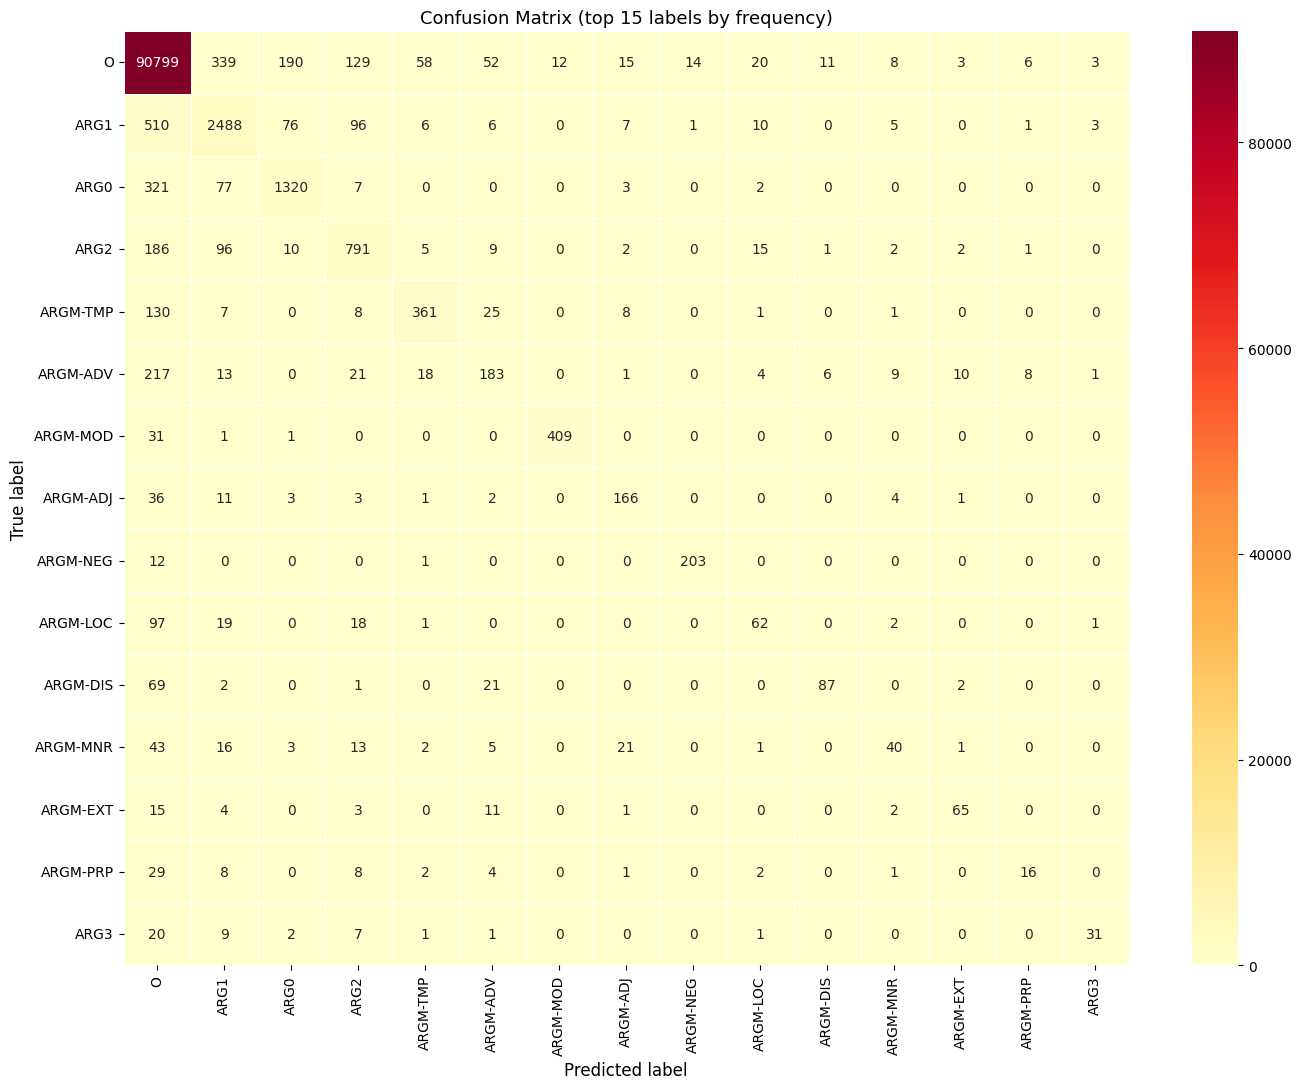

In [20]:
# Confusion matrix - top 15 labels by frequency
label_freq   = Counter(test_labels)
top15_labels = [l for l, _ in label_freq.most_common(15)]

# Filter predictions to top15 labels only
filtered = [(g, p) for g, p in zip(test_labels, preds) if g in top15_labels]
y_true_f = [g for g, _ in filtered]
y_pred_f = [p for _, p in filtered]

cm = confusion_matrix(y_true_f, y_pred_f, labels=top15_labels)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=top15_labels, yticklabels=top15_labels,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix (top 15 labels by frequency)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.1 Results Discussion

**Overall performance.** The model achieves reasonable F1 scores on the two most frequent core argument roles, ARG0 and ARG1, which aligns with expectations for a feature-based logistic regression system on this task. The dependency path feature provides strong signal for these labels since ARG0 is almost always the grammatical subject (`nsubj:up`) and ARG1 is typically the direct object (`dobj:up`).

**Easiest labels.** ARG0 and ARG1 are the most reliably predicted labels. The confusion matrix shows clear diagonal dominance for both. The `nsubj:up` path is a near-perfect predictor for ARG0, and `dobj:up` for ARG1 (as confirmed in the path analysis above).

**Most difficult labels.** Adjunct modifier roles (ARGM-TMP, ARGM-ADV, ARGM-MNR, ARGM-LOC) are harder to distinguish from each other and from O. These roles do not have distinctive syntactic positions, a prepositional phrase can fill any of them depending on semantics, which our surface-level features cannot capture. Additionally, rare labels like ARG3, ARG4, ARGM-CAU, and ARGM-COM have very few training examples, making it difficult for the model to learn reliable patterns.

**O label behavior.** The dominant O class creates a precision-recall tradeoff. The confusion matrix shows the main error pattern: argument tokens misclassified as O rather than as wrong argument types, suggesting the model is conservative rather than confused about which argument role to assign.

**Comparison to upper bound.** The BERT-based system (Assignment 2) is expected to substantially outperform this baseline by learning contextual representations that capture semantic distinctions our three features cannot.

## 5. Saved Predictions

In [21]:
# Save predictions TSV
import csv

pred_path = OUT_DIR / "predictions.tsv"
with open(pred_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f, delimiter="\t")
    w.writerow(["token", "gold_label", "predicted_label"])
    for row, g, p in zip(test_ws, test_labels, preds):
        w.writerow([row[2], g, p])

print(f"Saved {len(test_labels):,} predictions to {pred_path}")

# Preview
df_preds = pd.read_csv(pred_path, sep='\t')
df_preds.head(20)

Saved 101,144 predictions to output/predictions.tsv


,token,gold_label,predicted_label
0,What,O,O
1,if,O,O
2,Google,ARG1,ARG1
3,Morphed,O,O
4,Into,O,O
5,GoogleOS,ARG2,ARG1
6,?,O,O
7,What,O,O
8,if,O,O
9,Google,ARG0,ARG0


## 6. Inference on Standalone Sentences

The `predict_srl` function takes a tokenized sentence as a list of strings and a one-hot list indicating the predicate position. It returns a list of `(token, label)` pairs with the predicate token labeled `V`.

add model load??

In [22]:
def demo_srl(sentence, predicates):
    """
    Run SRL demo for a sentence with one or more predicates.
    Args:
        sentence:   list of token strings
        predicates: list of (predicate_word, one_hot_indicator) tuples
    """
    print(f"Sentence: {' '.join(sentence)}")
    print()
    for pred_word, indicators in predicates:
        result = predict_srl(sentence, indicators, model, vectorizer)
        print(f"  Predicate: '{pred_word}'")
        for tok, lbl in result:
            marker = "  <--" if lbl != 'O' else ""
            print(f"    {tok:15s} -> {lbl}{marker}")
        print()

In [23]:
# Example 1: sentence from assignment spec (two predicates)
sentence1 = ['Pia', 'asked', 'Luis', 'to', 'write', 'this', 'sentence', '.']

demo_srl(sentence1, [
    ('asked', [0, 1, 0, 0, 0, 0, 0, 0]),
    ('write', [0, 0, 0, 0, 1, 0, 0, 0]),
])

Sentence: Pia asked Luis to write this sentence .

  Predicate: 'asked'
    Pia             -> ARG0  <--
    asked           -> V  <--
    Luis            -> ARG2  <--
    to              -> O
    write           -> ARG1  <--
    this            -> O
    sentence        -> O
    .               -> O

  Predicate: 'write'
    Pia             -> ARG0  <--
    asked           -> O
    Luis            -> O
    to              -> O
    write           -> V  <--
    this            -> O
    sentence        -> ARG1  <--
    .               -> O



In [24]:
# Example 2: a longer sentence with two predicates
sentence2 = ['The', 'president', 'announced', 'that', 'Congress', 'approved', 'the', 'budget', '.']

demo_srl(sentence2, [
    ('announced', [0, 0, 1, 0, 0, 0, 0, 0, 0]),
    ('approved',  [0, 0, 0, 0, 0, 1, 0, 0, 0]),
])

Sentence: The president announced that Congress approved the budget .

  Predicate: 'announced'
    The             -> O
    president       -> ARG0  <--
    announced       -> V  <--
    that            -> O
    Congress        -> O
    approved        -> ARG1  <--
    the             -> O
    budget          -> O
    .               -> O

  Predicate: 'approved'
    The             -> O
    president       -> O
    announced       -> O
    that            -> O
    Congress        -> ARG0  <--
    approved        -> V  <--
    the             -> O
    budget          -> ARG1  <--
    .               -> O



In [25]:
# Example 3: passive sentence - ARG0 is not the subject
sentence3 = ['The', 'report', 'was', 'written', 'by', 'the', 'journalist', 'yesterday', '.']

demo_srl(sentence3, [
    ('written', [0, 0, 0, 1, 0, 0, 0, 0, 0]),
])

Sentence: The report was written by the journalist yesterday .

  Predicate: 'written'
    The             -> O
    report          -> ARG1  <--
    was             -> O
    written         -> V  <--
    by              -> O
    the             -> O
    journalist      -> ARG0  <--
    yesterday       -> ARGM-TMP  <--
    .               -> O

